# WIP!!! make specific stimulus events and update outputs

In [2]:
import os
from glob import glob
from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.fmriprep import load_confounds

## nilearn modeling: first level


Based on [nilearn examples](https://nilearn.github.io/auto_examples/04_glm_first_level/plot_bids_features.html#sphx-glr-auto-examples-04-glm-first-level-plot-bids-features-py)

In [49]:
# Rename events based on desired analysis
def update_events(models_events, event_type='sound'):
    # stimulus events
    if event_type == 'stimulus':
        for sx, sub_events in enumerate(models_events):
            for mx, run_events in enumerate(sub_events):
                run_events['trial_type'] = run_events['stim_file'].str.replace('.wav', '')
                run_events['trial_type'] = run_events['trial_type'].str.replace('-','_')

        # create stimulus list from updated events.tsv file
        stim_list = sorted([s for s in run_events['trial_type'].unique() if str(s) != 'nan'])
    
    # trial-specific events
    if event_type == 'trial':
        for sx, sub_events in enumerate(models_events):
            for mx, run_events in enumerate(sub_events):
                name_groups = run_events.groupby('stim_file')['stim_file']
                suffix = name_groups.cumcount() + 1
                #repeats = name_groups.transform('size')
                print(suffix)

                run_events['trial_type'] = run_events['stim_file'].str.replace('.wav', '') + \
                                           '_trial' + suffix.map(str)[:-2]
                                           
                run_events['trial_type'] = run_events['trial_type'].str.replace('-','_')
                run_events['trial_type'] = run_events['trial_type'].str.replace('.0','')

        # create stimulus list from updated events.tsv file
        stim_list = sorted([s for s in run_events['trial_type'].unique() if str(s) != 'nan'])

    # all sound events
    elif event_type == 'sound':
        for sx, sub_events in enumerate(models_events):
            for mx, run_events in enumerate(sub_events):
                orig_stim_list = sorted([str(s) for s in run_events['trial_type'].unique() if str(s) not in ['nan', 'None']])

                run_events['trial_type'] = run_events.trial_type.str.split('_', expand=True)[0]

        # create stimulus list from updated events.tsv file
        stim_list = sorted([str(s) for s in run_events['trial_type'].unique() if str(s) not in ['nan', 'None']])
    
    #print('stim list: ', stim_list)
    return stim_list, models_events


In [28]:
# transform full event design matrix (LSA) into single-event only (LSS)
def lss_transformer(event_df, event_name):
    other_idx = np.array(event_df.loc[:,'trial_type'] != event_name)
    lss_event_df = event_df.copy()
    lss_event_df.loc[other_idx, 'trial_type'] = 'other_events' 
    return lss_event_df


In [47]:
# Per-run GLM
def nilearn_glm_per_run(stim_list, task_label, 
                        models, models_run_imgs, 
                        models_events, 
                        models_confounds,
                        out_dir,
                        model_type='LSA'):
    from nilearn.reporting import make_glm_report
    from nilearn.interfaces.bids import save_glm_to_bids
    from nilearn.interfaces.fmriprep import load_confounds_strategy
    
    #for midx in range(len(models)):
    midx = 0 # only 1 subject per analysis
    model = models[midx]
    
    #contrast_list = stim_list
    for contrast_label in stim_list:
        #contrast_desc  = stim
        #print('Running for contrast', contrast_label)

        # set limited confounds
        print('selecting confounds')
        imgs = models_run_imgs[midx]
        confounds_ltd, sample_mask = load_confounds_strategy(img_files=imgs, 
                                                             denoise_strategy='compcor')
        for rx in range(len(confounds_ltd)):
            img = models_run_imgs[midx][rx]
            confound = confounds_ltd[rx]

            if model_type == 'LSA':
                event = models_events[midx][rx]
            elif model_type == 'LSS':
                event = lss_transformer(models_events[midx][rx], stim)
            print(event)

            #try:
            # fit the GLM
            print('fitting GLM')
            model.fit(img, event, confound); 
            print(model)

            # compute the contrast of interest
            print('computing contrast of interest')
            summary_statistics = model.compute_contrast(contrast_label, output_type='all')

            # save model outputs
            out_prefix = f"sub-{model.subject_label}_task-{task_label}_" + \
                         f"fwhm-{model.smoothing_fwhm}_run-{rx+1}"
            save_glm_to_bids(model, 
                             contrast_label,
                             out_dir=out_dir,
                             prefix=out_prefix,
                            )
            print(f'Saved model outputs to {bidsderiv_dir}')

            #except:
            #    print('could not run for ', contrast_label)
    return summary_statistics


## Run pipelines

In [50]:
task_label  = 'badaga'
space_label = 'MNI152NLin2009cAsym'
event_type  = 'stimulus'

t_acq = 2
t_r = t_acq # same as t_acq since no silent gap in this acquisition

# correct the fmriprep-given slice reference (middle slice, or 0.5)
slice_time_ref = 0.5 * t_acq / t_r

# define bids and fmriprep directories
project_dir = os.path.join('/bgfs/bchandrasekaran/krs228/data/', 
                           'SSP/')
bidsroot = os.path.join(project_dir, 
                        'data_bids')
fmriprep_dir = os.path.join(bidsroot, 
                            'derivatives', 
                            'fmriprep-23.2.1',
                            )
print('bidsroot: ', bidsroot)
print('fmriprep dir:', fmriprep_dir)

# create output directory
bidsderiv_dir = os.path.join(bidsroot, 
                             'derivatives', 
                             'nilearn', 
                             f'run-specific_eventtype-{event_type}')
if not os.path.exists(bidsderiv_dir):
    os.makedirs(bidsderiv_dir)

bidsroot:  /bgfs/bchandrasekaran/krs228/data/SSP/data_bids
fmriprep dir: /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/fmriprep-23.2.1


### Event modeling

Takes approximately 30 minutes per subject

**from Ashley Feb 3, 2025:**

So, please IGNORE for now:
- 001
- 002
- 005
- 014
- 072
- (and maybe 069?)

In [43]:
fwhm = 6
subject_list = ['SSP009', #'SSP011', 
                #'SSP012', 'SSP013', # only 2 beh events files ?
                #'SSP017', 'SSP018',
                #'SSP020', 'SSP028', 'SSP032', 'SSP033',
                #'SSP034', 'SSP036', 'SSP038', 'SSP039',
                #'SSP040', 
                #'SSP041', 'SSP038', 'SSP045',
                #'SSP046', 'SSP048', 'SSP051', 'SSP054',
                #'SSP058', 'SSP059', 'SSP069',
                ] # 


In [ ]:
for sx, subject_id in enumerate(subject_list):
    print('Running subject', subject_id)
    
    models, models_run_imgs, \
            raw_models_events, \
            models_confounds = first_level_from_bids(bidsroot, 
                                                     task_label, 
                                                     space_label=space_label,
                                                     sub_labels=[subject_id],
                                                     smoothing_fwhm=fwhm,
                                                     derivatives_folder=fmriprep_dir,
                                                     slice_time_ref=slice_time_ref,
                                                     minimize_memory=False)


    stim_list, models_events = update_events(raw_models_events, 
                                             event_type=event_type)
   
    # Per-run GLM
    summary_statistics = nilearn_glm_per_run(stim_list, task_label, 
                                             models, models_run_imgs, 
                                             models_events, 
                                             models_confounds,
                                             out_dir=bidsderiv_dir)


Running subject SSP009


/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/glm/first_level/first_level.py:1621: UserWarning: 'slice_time_ref' provided (0.5) is different from the value found in the BIDS dataset (0.174).
Note this may lead to the wrong model specification.
  warn(


selecting confounds
     Unnamed: 0       onset  duration trial_type     stim_file syllable  \
0             0    0.000000       0.3    GA_M2_Q   GA_M2_Q.wav       GA   
1             1    1.891344       0.1        NaN           NaN      NaN   
2             2    2.756490       0.3    GA_M1_8   GA_M1_8.wav       GA   
3             3    3.891364       0.1        NaN           NaN      NaN   
4             4    4.751014       0.3    GA_M1_Q   GA_M1_Q.wav       GA   
..          ...         ...       ...        ...           ...      ...   
315         315  353.891579       0.1        NaN           NaN      NaN   
316         316  354.744311       0.3   MA_F1_n6  MA_F1_n6.wav       MA   
317         317  355.891611       0.1        NaN           NaN      NaN   
318         318  356.733526       0.3    BA_F2_0   BA_F2_0.wav       BA   
319         319  357.891732       0.1        NaN           NaN      NaN   

    speaker noise_level  response_time  correct_key  response_key  
0        M2

/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: speaker, response_time, response_key, syllable, Unnamed: 0, stim_file, correct_key, noise_level
  warnings.warn(
/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:208: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  warnings.warn(


FirstLevelModel(fir_delays=[0], memory=Memory(location=None),
                minimize_memory=False, slice_time_ref=0.5, smoothing_fwhm=6,
                subject_label='SSP009', t_r=2)
computing contrast of interest


...

/scratch/slurm-5066995/ipykernel_26668/2827584231.py:49: UserWarning: Contrast name "BA_M1_Q" changed to "baM1Q"
  save_glm_to_bids(model,


Saved model outputs to /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-specific_eventtype-stimulus
     Unnamed: 0       onset  duration trial_type     stim_file syllable  \
0             0    0.000000       0.3   BA_M2_n2  BA_M2_n2.wav       BA   
1             1    1.159848       0.1        NaN           NaN      NaN   
2             2    2.003781       0.3    DA_M1_8   DA_M1_8.wav       DA   
3             3    3.152228       0.1        NaN           NaN      NaN   
4             4    3.997105       0.3    BA_M1_Q   BA_M1_Q.wav       BA   
..          ...         ...       ...        ...           ...      ...   
315         315  351.151952       0.1        NaN           NaN      NaN   
316         316  352.010320       0.3   BA_F1_n2  BA_F1_n2.wav       BA   
317         317  353.161567       0.1        NaN           NaN      NaN   
318         318  354.022928       0.3   DA_F2_n6  DA_F2_n6.wav       DA   
319         319  355.152722       0.1        NaN    

/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: speaker, response_time, response_key, syllable, Unnamed: 0, stim_file, correct_key, noise_level
  warnings.warn(
/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:208: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  warnings.warn(


FirstLevelModel(fir_delays=[0], memory=Memory(location=None),
                minimize_memory=False, slice_time_ref=0.5, smoothing_fwhm=6,
                subject_label='SSP009', t_r=2)
computing contrast of interest


/scratch/slurm-5066995/ipykernel_26668/2827584231.py:49: UserWarning: Contrast name "BA_M1_Q" changed to "baM1Q"
  save_glm_to_bids(model,


In [ ]:
models_events[0]

In [ ]:
stim_list

# WIP

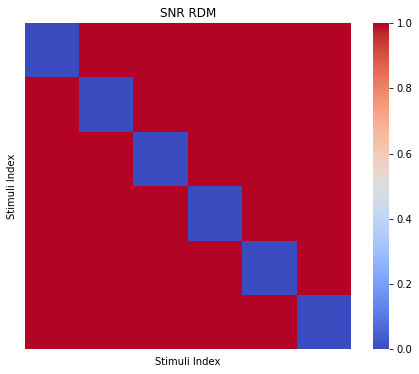

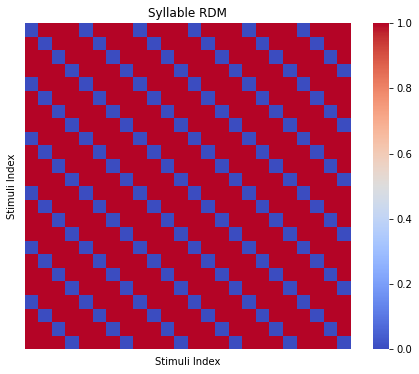

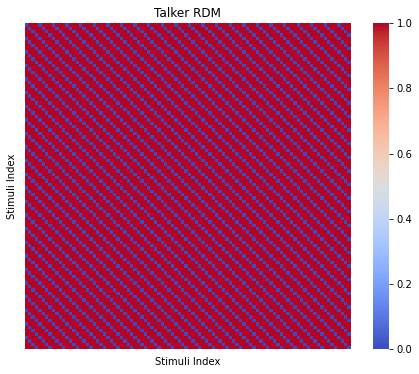

Example pattern descriptors (first 5):
0: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'F1'}
1: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'F2'}
2: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'M1'}
3: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'M2'}
4: {'SNR': 'Q', 'Syllable': 'da', 'Talker': 'F1'}


In [1]:
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

# Define categorical variables
snrs = ["Q", "8", "2", "0", "N2", "N6"]  # 6 SNRs
syllables = ["ba", "da", "ga", "ma"]  # 4 Syllables
talkers = ["F1", "F2", "M1", "M2"]  # 4 Talkers

# Generate all possible stimuli (6 SNRs × 4 Syllables × 4 Talkers = 96 stimuli)
stimuli = list(itertools.product(snrs, syllables, talkers))  # 96 stimuli

# Create the pattern_descriptors dictionary
pattern_descriptors = {
    idx: {"SNR": stim[0], "Syllable": stim[1], "Talker": stim[2]} 
    for idx, stim in enumerate(stimuli)
}

# Initialize RDMs (96x96 matrices)
rdm_snr = np.zeros((96, 96), dtype=int)
rdm_syllable = np.zeros((96, 96), dtype=int)
rdm_talker = np.zeros((96, 96), dtype=int)

# Fill RDMs
for i in range(96):
    for j in range(96):
        # SNR RDM: 1 if different SNRs, 0 if same
        rdm_snr[i, j] = 1 if pattern_descriptors[i]["SNR"] != pattern_descriptors[j]["SNR"] else 0

        # Syllable RDM: 1 if different syllables, 0 if same
        rdm_syllable[i, j] = 1 if pattern_descriptors[i]["Syllable"] != pattern_descriptors[j]["Syllable"] else 0

        # Talker RDM: 1 if different talkers, 0 if same
        rdm_talker[i, j] = 1 if pattern_descriptors[i]["Talker"] != pattern_descriptors[j]["Talker"] else 0

# Function to plot an RDM
def plot_rdm(matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, cmap="coolwarm", cbar=True, square=True, xticklabels=False, yticklabels=False)
    plt.title(title)
    plt.xlabel("Stimuli Index")
    plt.ylabel("Stimuli Index")
    plt.show()

# Plot the three RDMs
plot_rdm(rdm_snr, "SNR RDM")
plot_rdm(rdm_syllable, "Syllable RDM")
plot_rdm(rdm_talker, "Talker RDM")

# Print example of pattern descriptors
print("Example pattern descriptors (first 5):")
for k in range(5):
    print(f"{k}: {pattern_descriptors[k]}")


In [2]:
pattern_descriptors

{0: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'F1'},
 1: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'F2'},
 2: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'M1'},
 3: {'SNR': 'Q', 'Syllable': 'ba', 'Talker': 'M2'},
 4: {'SNR': 'Q', 'Syllable': 'da', 'Talker': 'F1'},
 5: {'SNR': 'Q', 'Syllable': 'da', 'Talker': 'F2'},
 6: {'SNR': 'Q', 'Syllable': 'da', 'Talker': 'M1'},
 7: {'SNR': 'Q', 'Syllable': 'da', 'Talker': 'M2'},
 8: {'SNR': 'Q', 'Syllable': 'ga', 'Talker': 'F1'},
 9: {'SNR': 'Q', 'Syllable': 'ga', 'Talker': 'F2'},
 10: {'SNR': 'Q', 'Syllable': 'ga', 'Talker': 'M1'},
 11: {'SNR': 'Q', 'Syllable': 'ga', 'Talker': 'M2'},
 12: {'SNR': 'Q', 'Syllable': 'ma', 'Talker': 'F1'},
 13: {'SNR': 'Q', 'Syllable': 'ma', 'Talker': 'F2'},
 14: {'SNR': 'Q', 'Syllable': 'ma', 'Talker': 'M1'},
 15: {'SNR': 'Q', 'Syllable': 'ma', 'Talker': 'M2'},
 16: {'SNR': '8', 'Syllable': 'ba', 'Talker': 'F1'},
 17: {'SNR': '8', 'Syllable': 'ba', 'Talker': 'F2'},
 18: {'SNR': '8', 'Syllable': 'ba', 'Talker': 'M1'},
 19

In [3]:
for rx in range(6):
    print(rx)

0
1
2
3
4
5


In [5]:
x = ['/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-specific_eventtype-stimulus/sub-SSP009/sub-SSP009_task-badaga_fwhm-6.0_run-1_contrast-maM2N2_stat-t_statmap.nii.gz']

In [6]:
x[0]

'/bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/nilearn/run-specific_eventtype-stimulus/sub-SSP009/sub-SSP009_task-badaga_fwhm-6.0_run-1_contrast-maM2N2_stat-t_statmap.nii.gz'